# OCR Validation methods

In [67]:
!pip install jiwer python-Levenshtein

  Using cached python_levenshtein-0.27.1-py3-none-any.whl.metadata (3.7 kB)
Using cached python_levenshtein-0.27.1-py3-none-any.whl (9.4 kB)


### From VIA Validation

In [68]:
import json

with open("test/via_project_7Aug2025_12h18m.json", "r", encoding="utf-8") as f:
    json_data = f.read()

data = json.loads(json_data)

# Extract text from each region
image_key = next(iter(data['_via_img_metadata']))
regions = data['_via_img_metadata'][image_key]['regions']

# Build the list of text entries
validation_words = [region['region_attributes'].get('text', '') for region in regions]

### From Qwen and Tesseract

In [80]:
# Qwen

with open("test/test-Yves_026_None_via_qwen.json", "r", encoding="utf-8") as f:
    qwen_data = f.read()

qwen_data = json.loads(qwen_data)

# Extract text from each region in Qwen data
regions_qwen = qwen_data['test-Yves_026_None.png']['regions']
qwen_words = [region['region_attributes'].get('text', '') for region in regions_qwen if 'region_attributes' in region]
print(qwen_words)


# Tesseract
with open("test/test-Yves_026_None_via_tesseract.json", "r", encoding="utf-8") as f:
    tesseract_data = f.read()

tesseract_data = json.loads(tesseract_data)

# Extract text from each region in Tesseract data
regions_tesseract = tesseract_data['test-Yves_026_None.png']['regions']
tesseract_words = [region['region_attributes'].get('text', '') for region in regions_tesseract]
print(tesseract_words)


['Delbouye', 'due', 'Adrien', 'levant', 'due', 'Marais', '3', 'due', 'chasse', 'nord', 'du', 'la', '2', 'tenant', 'loi', 'conformément', 'pourra', 'la', '人', 'prorogée', 'être', 'Elle', 'Valenciennes', '3', 'Mons', 'route', 'de', 'class', 'de', 'front', 'terrain', 'environ', 'ares', '3', 'de', 'sur', '53', 'présent', 'acte', 'cours', 'du', 'date', 'prendront', 'la', '2', 'tou', 'exploitation', 'bâti', 'le', 'son', 'ca', 'servant', 'you', "l'établissement", 'qui', 'dans', 'trouvant', 'années', 'vingt', 'term', 'pour', 'de', 'un', 'est', 'constituée', 'société', 'Art', 'La', '4', 'par', 'ser', 'destination', 'immeubles', 'quelconques', 'généralement', 'mobiliers', 'objets', 'Boussu.', 'est', 'tà', 'social', 'siège', 'Art.', 'Le', '3', 'autres', 'et', 'machines', 'ustensiles', 'que', 'sales', 'tous', 'ainsi', 'réservé', 'ni', 'excepté', 'glaces', 'verre', 'des', 'et', 'du', 'rien', 'dépendances', "d'ouvriers", 'set', 'et', "d'employés", 'maisons', "d'habitation", 'commerce', 'maison', 'au

## Preprocessing of data
-> Meaning is most important

In [81]:
ids = []

validation_words_use = validation_words.copy()
qwen_words_use = qwen_words.copy()
tesseract_words_use = tesseract_words.copy()

# Find indices of '####' in validation_words
# This is used to identify words that are not recognized or are placeholders
for i, box in enumerate(validation_words_use):
    if box == '####':
        ids.append(i)

for id in ids:
    validation_words_use[id] = ''  # Clear the placeholder
    qwen_words_use[id] = ''
    tesseract_words_use[id] = ''


## Validate

### CER, WER and Leven on all words

In [82]:
# CER
from jiwer import cer

ref = ' '.join(validation_words_use)
qwen = ' '.join(qwen_words_use)
tess = ' '.join(tesseract_words_use)

cer_qwen = cer(ref, qwen)
cer_tesseract = cer(ref, tess)

print(f"CER Qwen: {cer_qwen}")
print(f"CER Tesseract: {cer_tesseract}")

CER Qwen: 0.015890291684806268
CER Tesseract: 0.11863299956464954


In [83]:
# WER
from jiwer import wer

ref = ' '.join(validation_words_use)
qwen = ' '.join(qwen_words_use)
tess = ' '.join(tesseract_words_use)

wer_qwen = wer(ref, qwen)
wer_tesseract = wer(ref, tess)

print(f"WER Qwen: {wer_qwen}")
print(f"WER Tesseract: {wer_tesseract}")

WER Qwen: 0.07891332470892626
WER Tesseract: 0.48382923673997413


In [84]:
from Levenshtein import distance

ref_str = ' '.join(validation_words_use)
qwen_str = ' '.join(qwen_words_use)
tess_str = ' '.join(tesseract_words_use)

lev_qwen = distance(ref_str, qwen_str) / len(ref_str)
lev_tesseract = distance(ref_str, tess_str) / len(ref_str)

print(f"Levenshtein Qwen: {lev_qwen}")
print(f"Levenshtein Tesseract: {lev_tesseract}")

Levenshtein Qwen: 0.015890291684806268
Levenshtein Tesseract: 0.11863299956464954


## Do not take into account capitalization and punctuation

In [85]:
import string

def preprocess(words):
    table = str.maketrans('', '', string.punctuation)
    return [w.lower().translate(table) for w in words]

validation_words_use_nopunct = preprocess(validation_words_use)
qwen_words_use_nopunct = preprocess(qwen_words_use)
tesseract_words_use_nopunct = preprocess(tesseract_words_use)

### CER, WER and Leven

The CER is slightly higher than when no normalization is done. This seems strange but is perfectly logical, since there are a lot less characters so when normalized CER is higher

In [86]:
ref_str = ' '.join(validation_words_use_nopunct)
hyp_qwen_str = ' '.join(qwen_words_use_nopunct)
hyp_tess_str = ' '.join(tesseract_words_use_nopunct)

cer_qwen_NP = cer(ref_str, hyp_qwen_str)
cer_tesseract_NP = cer(ref_str, hyp_tess_str)

print(f"CER Qwen (normalized): {cer_qwen_NP}")
print(f"CER Tesseract (normalized): {cer_tesseract_NP}")

wer_qwen_NP = wer(ref_str, hyp_qwen_str)
wer_tesseract_NP = wer(ref_str, hyp_tess_str)

print(f"WER Qwen (normalized): {wer_qwen_NP}")
print(f"WER Tesseract (normalized): {wer_tesseract_NP}")

lev_qwen_NP = distance(ref_str, hyp_qwen_str) / len(ref_str)
lev_tesseract_NP = distance(ref_str, hyp_tess_str) / len(ref_str)

print(f"Levenshtein Qwen (normalized): {lev_qwen_NP}")
print(f"Levenshtein Tesseract (normalized): {lev_tesseract_NP}")

CER Qwen (normalized): 0.016035634743875277
CER Tesseract (normalized): 0.07216035634743875
WER Qwen (normalized): 0.07792207792207792
WER Tesseract (normalized): 0.33896103896103896
Levenshtein Qwen (normalized): 0.016035634743875277
Levenshtein Tesseract (normalized): 0.07216035634743875


# Only numbers

In [87]:
import re

# Filter lists to only words containing digits

validation_digits = []
qwen_digits = []
tesseract_digits = []

for idx, box in enumerate(validation_words_use):
    if re.search(r'\d', box):
        validation_digits.append(validation_words_use[idx])
        qwen_digits.append(qwen_words_use[idx])
        tesseract_digits.append(tesseract_words_use[idx])

ref_digits_str = ' '.join(validation_digits)
qwen_digits_str = ' '.join(qwen_digits)
tess_digits_str = ' '.join(tesseract_digits)

# CER
cer_qwen_digits = cer(ref_digits_str, qwen_digits_str)
cer_tesseract_digits = cer(ref_digits_str, tess_digits_str)
print(f"CER Qwen (digits only): {cer_qwen_digits}")
print(f"CER Tesseract (digits only): {cer_tesseract_digits}")

# WER
wer_qwen_digits = wer(ref_digits_str, qwen_digits_str)
wer_tesseract_digits = wer(ref_digits_str, tess_digits_str)
print(f"WER Qwen (digits only): {wer_qwen_digits}")
print(f"WER Tesseract (digits only): {wer_tesseract_digits}")

# Levenshtein
lev_qwen_digits = distance(ref_digits_str, qwen_digits_str) / len(ref_digits_str) if len(ref_digits_str) > 0 else 0
lev_tesseract_digits = distance(ref_digits_str, tess_digits_str) / len(ref_digits_str) if len(ref_digits_str) > 0 else 0
print(f"Levenshtein Qwen (digits only): {lev_qwen_digits}")
print(f"Levenshtein Tesseract (digits only): {lev_tesseract_digits}")

CER Qwen (digits only): 0.004728132387706856
CER Tesseract (digits only): 0.2978723404255319
WER Qwen (digits only): 0.021052631578947368
WER Tesseract (digits only): 0.9052631578947369
Levenshtein Qwen (digits only): 0.004728132387706856
Levenshtein Tesseract (digits only): 0.2978723404255319


# Influence of long words

In [88]:
validation_long_words = []
qwen_long_words = []
tesseract_long_words = []

for idx, box in enumerate(validation_words_use):
    if len(box) >= 3:
        validation_long_words.append(validation_words_use[idx])
        qwen_long_words.append(qwen_words_use[idx])
        tesseract_long_words.append(tesseract_words_use[idx])

ref_long_str = ' '.join(validation_long_words)
qwen_long_str = ' '.join(qwen_long_words)
tess_long_str = ' '.join(tesseract_long_words)

# CER
cer_qwen_long = cer(ref_long_str, qwen_long_str)
cer_tesseract_long = cer(ref_long_str, tess_long_str)
print(f"CER Qwen (long words): {cer_qwen_long}")
print(f"CER Tesseract (long words): {cer_tesseract_long}")

# WER
wer_qwen_long = wer(ref_long_str, qwen_long_str)
wer_tesseract_long = wer(ref_long_str, tess_long_str)
print(f"WER Qwen (long words): {wer_qwen_long}")
print(f"WER Tesseract (long words): {wer_tesseract_long}")

# Levenshtein
lev_qwen_long = distance(ref_long_str, qwen_long_str) / len(ref_long_str)
lev_tesseract_long = distance(ref_long_str, tess_long_str) / len(ref_long_str)
print(f"Levenshtein Qwen (long words): {lev_qwen_long}")
print(f"Levenshtein Tesseract (long words): {lev_tesseract_long}")

CER Qwen (long words): 0.005633802816901409
CER Tesseract (long words): 0.10448143405889884
WER Qwen (long words): 0.03612167300380228
WER Tesseract (long words): 0.5190114068441065
Levenshtein Qwen (long words): 0.005633802816901409
Levenshtein Tesseract (long words): 0.10448143405889884


# Some visualization

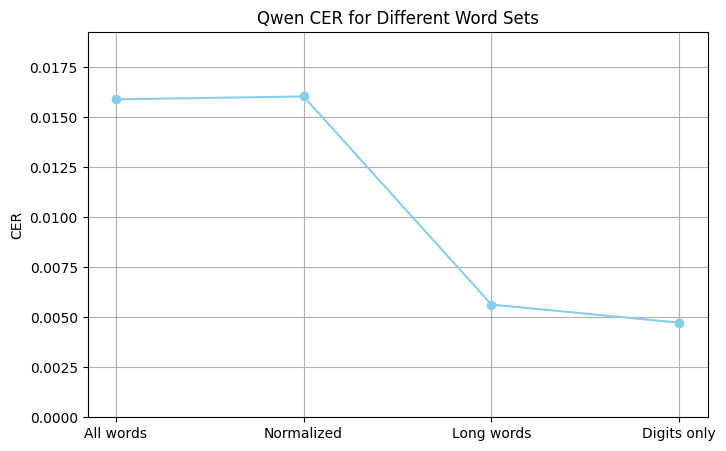

In [90]:
import matplotlib.pyplot as plt

# Collect all Qwen CER values
cer_values = {
    "All words": cer_qwen,
    "Normalized": cer_qwen_NP,
    "Long words": cer_qwen_long,
    "Digits only": cer_qwen_digits
}

plt.figure(figsize=(8, 5))
plt.plot(list(cer_values.keys()), list(cer_values.values()), marker='o', color='skyblue')
plt.ylabel("CER")
plt.title("Qwen CER for Different Word Sets")
plt.ylim(0, max(cer_values.values()) * 1.2)
plt.grid(True)
plt.show()

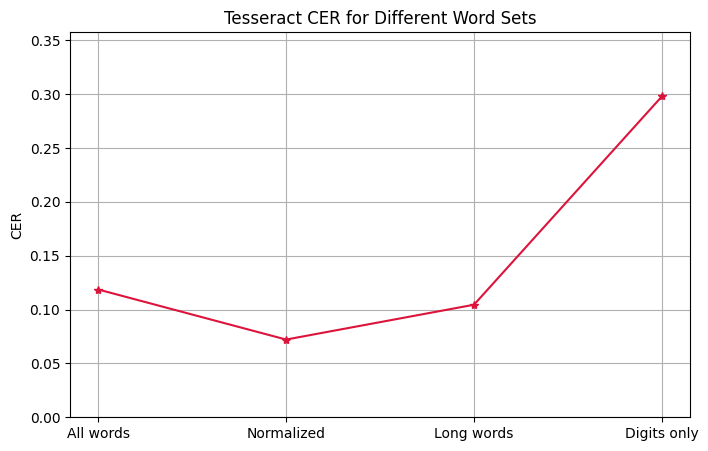

In [93]:
# Collect all Qwen CER values
cer_values = {
    "All words": cer_tesseract,
    "Normalized": cer_tesseract_NP,
    "Long words": cer_tesseract_long,
    "Digits only": cer_tesseract_digits
}

plt.figure(figsize=(8, 5))
plt.plot(list(cer_values.keys()), list(cer_values.values()), marker='*', color='crimson')
plt.ylabel("CER")
plt.title("Tesseract CER for Different Word Sets")
plt.ylim(0, max(cer_values.values()) * 1.2)
plt.grid(True)
plt.show()

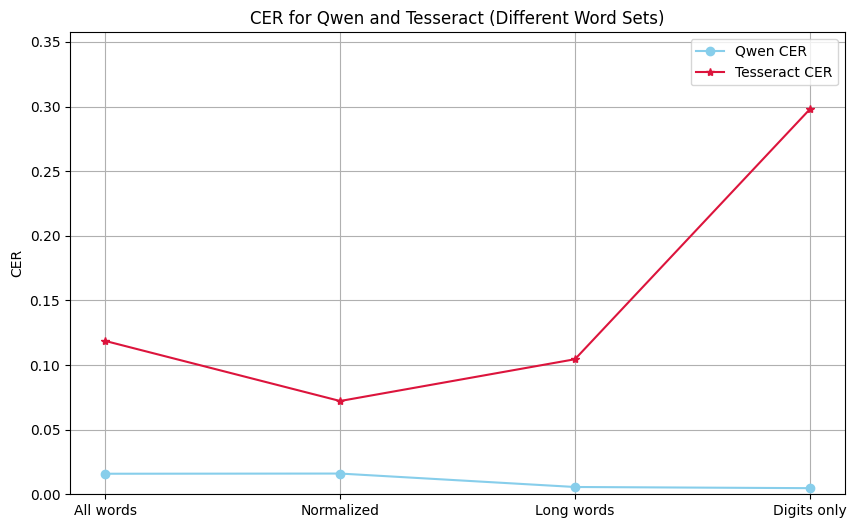

In [94]:
plt.figure(figsize=(10, 6))

# Qwen CER values
cer_qwen_values = [
    cer_qwen,
    cer_qwen_NP,
    cer_qwen_long,
    cer_qwen_digits
]
# Tesseract CER values
cer_tesseract_values = [
    cer_tesseract,
    cer_tesseract_NP,
    cer_tesseract_long,
    cer_tesseract_digits
]
labels = ["All words", "Normalized", "Long words", "Digits only"]

plt.plot(labels, cer_qwen_values, marker='o', color='skyblue', label='Qwen CER')
plt.plot(labels, cer_tesseract_values, marker='*', color='crimson', label='Tesseract CER')
plt.ylabel("CER")
plt.title("CER for Qwen and Tesseract (Different Word Sets)")
plt.ylim(0, max(cer_qwen_values + cer_tesseract_values) * 1.2)
plt.grid(True)
plt.legend()
plt.show()

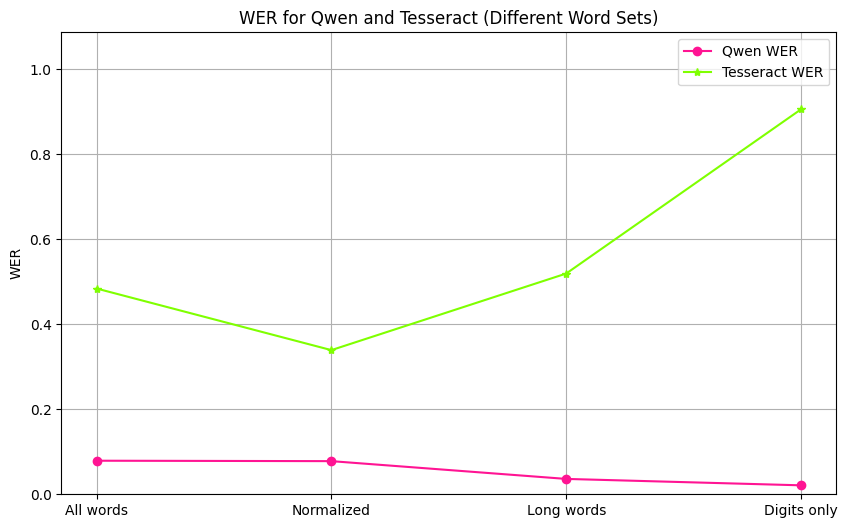

In [97]:
plt.figure(figsize=(10, 6))

# Qwen WER values
wer_qwen_values = [
    wer_qwen,
    wer_qwen_NP,
    wer_qwen_long,
    wer_qwen_digits
]
# Tesseract WER values
wer_tesseract_values = [
    wer_tesseract,
    wer_tesseract_NP,
    wer_tesseract_long,
    wer_tesseract_digits
]
labels = ["All words", "Normalized", "Long words", "Digits only"]

plt.plot(labels, wer_qwen_values, marker='o', color='deeppink', label='Qwen WER')
plt.plot(labels, wer_tesseract_values, marker='*', color='chartreuse', label='Tesseract WER')
plt.ylabel("WER")
plt.title("WER for Qwen and Tesseract (Different Word Sets)")
plt.ylim(0, max(wer_qwen_values + wer_tesseract_values) * 1.2)
plt.grid(True)
plt.legend()
plt.show()

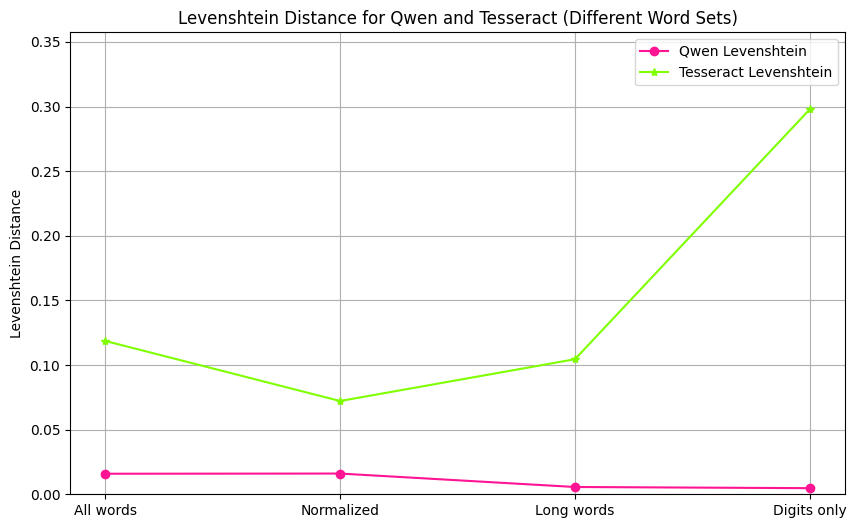

In [98]:
plt.figure(figsize=(10, 6))

# Qwen WER values
lev_qwen_values = [
    lev_qwen,
    lev_qwen_NP,
    lev_qwen_long,
    lev_qwen_digits
]
# Tesseract WER values
lev_tesseract_values = [
    lev_tesseract,
    lev_tesseract_NP,
    lev_tesseract_long,
    lev_tesseract_digits
]
labels = ["All words", "Normalized", "Long words", "Digits only"]

plt.plot(labels, lev_qwen_values, marker='o', color='deeppink', label='Qwen Levenshtein')
plt.plot(labels, lev_tesseract_values, marker='*', color='chartreuse', label='Tesseract Levenshtein')
plt.ylabel("Levenshtein Distance")
plt.title("Levenshtein Distance for Qwen and Tesseract (Different Word Sets)")
plt.ylim(0, max(lev_qwen_values + lev_tesseract_values) * 1.2)
plt.grid(True)
plt.legend()
plt.show()